# CartPole-v1 Algorithm Comparison: Tabular Q-Learning, SARSA with Tile Coding, and REINFORCE with Baseline

This notebook compares three reinforcement learning algorithms from different method families on one environment, `CartPole-v1`.

The implementation reuses and adapts ideas from the provided weekly notebooks:

- **Week 4:** online TD control with tabular Q-learning.
- **Week 5:** tile coding with semi-gradient SARSA for continuous observations.
- **Week 6:** REINFORCE with a learned state-value baseline using PyTorch.

## Required scope covered

- Environment: `CartPole-v1`
- Algorithms:
  1. Tabular Q-Learning with discretized continuous states
  2. SARSA with Tile Coding
  3. REINFORCE with Baseline
- Experimental setup:
  - 3 random seeds per algorithm
  - 500 episodes per final run
  - light hyperparameter tuning before final comparison
- Outputs:
  - learning curves with error bands
  - final performance bar chart with error bars
  - brief trade-off analysis

In [1]:
# Install dependencies if needed.
# In many course environments these are already installed.
try:
    import gymnasium as gym
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install "gymnasium[classic-control]"
    import gymnasium as gym

try:
    import torch
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install torch
    import torch

In [2]:
import os
import random
from dataclasses import dataclass
from itertools import product
from typing import Dict, List, Sequence, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Gymnasium:", gym.__version__)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

Gymnasium: 1.2.3
PyTorch: 2.11.0
Device: cpu


## 1. Environment inspection

CartPole has a continuous 4-dimensional observation space, so a purely tabular method cannot use the raw state directly. For the tabular Q-learning agent, this notebook discretizes the continuous observation into bins. For SARSA, tile coding creates overlapping binary features. For REINFORCE, the neural network uses the raw continuous state.

In [3]:
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=123)
summary_df = pd.DataFrame({
    "Property": ["Observation space", "Action space", "Initial observation", "Max episode steps"],
    "Value": [str(env.observation_space), str(env.action_space), obs, env.spec.max_episode_steps]
})
env.close()
summary_df

,Property,Value
0,Observation space,"Box([-4.8 -inf -0.4189 -inf], [4.8 ..."
1,Action space,Discrete(2)
2,Initial observation,"[0.018235186, -0.0446179, -0.027964013, -0.031..."
3,Max episode steps,500


## 2. Shared helper functions

In [4]:
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_env(seed: int):
    env = gym.make("CartPole-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env


def epsilon_by_episode(ep: int, n_episodes: int, eps_start: float, eps_end: float) -> float:
    frac = min(ep / max(n_episodes - 1, 1), 1.0)
    return eps_start + frac * (eps_end - eps_start)


def moving_average(x: Sequence[float], window: int = 25) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x.copy()
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


def mean_ci95(arr_2d: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Mean and 95% confidence interval across seeds."""
    mean = arr_2d.mean(axis=0)
    if arr_2d.shape[0] <= 1:
        ci = np.zeros_like(mean)
    else:
        ci = 1.96 * arr_2d.std(axis=0, ddof=1) / np.sqrt(arr_2d.shape[0])
    return mean, ci


def summarize_final_performance(results_df: pd.DataFrame, final_window: int = 100) -> pd.DataFrame:
    rows = []
    for (algorithm, seed), sub in results_df.groupby(["algorithm", "seed"]):
        final_avg = sub.tail(final_window)["return"].mean()
        best_return = sub["return"].max()
        rows.append({
            "algorithm": algorithm,
            "seed": seed,
            f"final_{final_window}_episode_avg": final_avg,
            "best_return": best_return,
        })
    return pd.DataFrame(rows)

## 3. Algorithm 1: Tabular Q-Learning with discretization

This adapts the Week 4 tabular Q-learning idea to CartPole. Because CartPole observations are continuous, each observation is first mapped into a discrete bin index. The Q-table then stores values for `(discrete_state, action)`.

Key tuned hyperparameters: number of bins and learning rate `alpha`.

In [5]:
class Discretizer:
    """Convert CartPole's continuous observations into a discrete state index."""
    def __init__(self, bins_per_dim: Tuple[int, int, int, int]):
        self.bins_per_dim = bins_per_dim
        # Clip extreme velocity dimensions because CartPole reports infinite bounds.
        self.low = np.array([-2.4, -3.0, -0.2095, -3.5], dtype=float)
        self.high = np.array([2.4, 3.0, 0.2095, 3.5], dtype=float)
        self.edges = [
            np.linspace(self.low[i], self.high[i], bins_per_dim[i] + 1)[1:-1]
            for i in range(4)
        ]
        self.n_states = int(np.prod(bins_per_dim))

    def transform(self, obs: np.ndarray) -> int:
        clipped = np.clip(obs, self.low, self.high)
        coords = tuple(int(np.digitize(clipped[i], self.edges[i])) for i in range(4))
        return int(np.ravel_multi_index(coords, self.bins_per_dim))


def q_epsilon_greedy(Q: np.ndarray, state: int, epsilon: float, rng: np.random.Generator) -> int:
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    return int(np.argmax(Q[state]))


def train_tabular_q_learning(
    seed: int,
    n_episodes: int = 500,
    bins_per_dim: Tuple[int, int, int, int] = (6, 8, 10, 8),
    alpha: float = 0.2,
    gamma: float = 0.99,
    eps_start: float = 1.0,
    eps_end: float = 0.05,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    env = make_env(seed)
    discretizer = Discretizer(bins_per_dim)
    Q = np.zeros((discretizer.n_states, env.action_space.n), dtype=float)
    history = []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        state = discretizer.transform(obs)
        epsilon = epsilon_by_episode(ep - 1, n_episodes, eps_start, eps_end)
        done = False
        total_reward = 0.0
        steps = 0

        while not done:
            action = q_epsilon_greedy(Q, state, epsilon, rng)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretizer.transform(next_obs)

            target = reward if done else reward + gamma * np.max(Q[next_state])
            Q[state, action] += alpha * (target - Q[state, action])

            state = next_state
            total_reward += reward
            steps += 1

        history.append({
            "algorithm": "Tabular Q-Learning",
            "seed": seed,
            "episode": ep,
            "return": total_reward,
            "steps": steps,
            "alpha": alpha,
            "bins": str(bins_per_dim),
            "eps_start": eps_start,
            "eps_end": eps_end,
        })

    env.close()
    return pd.DataFrame(history)

## 4. Algorithm 2: Semi-gradient SARSA with tile coding

This adapts the Week 5 tile-coding SARSA structure to CartPole. Instead of storing a Q-table for every possible continuous state, the state activates several tiles, and each action has its own weight vector.

Key tuned hyperparameters: number of tilings and learning rate `alpha`.

In [6]:
@dataclass
class TileCoder:
    low: np.ndarray
    high: np.ndarray
    num_tilings: int = 8
    tiles_per_dim: Tuple[int, int, int, int] = (6, 6, 8, 6)

    def __post_init__(self):
        self.low = np.asarray(self.low, dtype=float)
        self.high = np.asarray(self.high, dtype=float)
        self.tile_width = (self.high - self.low) / np.asarray(self.tiles_per_dim)
        self.tiles_per_tiling = int(np.prod(self.tiles_per_dim))
        self.n_features = self.num_tilings * self.tiles_per_tiling

    def active_tiles(self, obs: np.ndarray) -> np.ndarray:
        obs = np.clip(obs, self.low, self.high)
        active = []
        for tiling in range(self.num_tilings):
            offset_frac = tiling / self.num_tilings
            shifted = obs - self.low + offset_frac * self.tile_width
            coords = np.floor(shifted / self.tile_width).astype(int)
            coords = np.clip(coords, 0, np.asarray(self.tiles_per_dim) - 1)
            local_index = np.ravel_multi_index(tuple(coords), self.tiles_per_dim)
            active.append(tiling * self.tiles_per_tiling + local_index)
        return np.asarray(active, dtype=int)


def tile_q_values(weights: np.ndarray, active: np.ndarray) -> np.ndarray:
    return weights[:, active].sum(axis=1)


def tile_epsilon_greedy(weights: np.ndarray, active: np.ndarray, epsilon: float, rng: np.random.Generator) -> int:
    if rng.random() < epsilon:
        return int(rng.integers(weights.shape[0]))
    return int(np.argmax(tile_q_values(weights, active)))


def train_tile_sarsa(
    seed: int,
    n_episodes: int = 500,
    num_tilings: int = 8,
    tiles_per_dim: Tuple[int, int, int, int] = (6, 6, 8, 6),
    alpha: float = 0.1,
    gamma: float = 0.99,
    eps_start: float = 0.5,
    eps_end: float = 0.02,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    env = make_env(seed)
    low = np.array([-2.4, -3.0, -0.2095, -3.5], dtype=float)
    high = np.array([2.4, 3.0, 0.2095, 3.5], dtype=float)
    tc = TileCoder(low=low, high=high, num_tilings=num_tilings, tiles_per_dim=tiles_per_dim)
    weights = np.zeros((env.action_space.n, tc.n_features), dtype=float)
    step_size = alpha / num_tilings
    history = []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        active = tc.active_tiles(obs)
        epsilon = epsilon_by_episode(ep - 1, n_episodes, eps_start, eps_end)
        action = tile_epsilon_greedy(weights, active, epsilon, rng)
        done = False
        total_reward = 0.0
        steps = 0

        while not done:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_active = tc.active_tiles(next_obs)

            current_q = weights[action, active].sum()
            if done:
                target = reward
                td_error = target - current_q
                weights[action, active] += step_size * td_error
            else:
                next_epsilon = epsilon_by_episode(ep - 1, n_episodes, eps_start, eps_end)
                next_action = tile_epsilon_greedy(weights, next_active, next_epsilon, rng)
                target = reward + gamma * weights[next_action, next_active].sum()
                td_error = target - current_q
                weights[action, active] += step_size * td_error
                action = next_action
                active = next_active

            total_reward += reward
            steps += 1

        history.append({
            "algorithm": "SARSA + Tile Coding",
            "seed": seed,
            "episode": ep,
            "return": total_reward,
            "steps": steps,
            "alpha": alpha,
            "num_tilings": num_tilings,
            "tiles_per_dim": str(tiles_per_dim),
            "eps_start": eps_start,
            "eps_end": eps_end,
        })

    env.close()
    return pd.DataFrame(history)

## 5. Algorithm 3: REINFORCE with learned baseline

This adapts the Week 6 policy-gradient implementation. The policy network samples actions, and a value network estimates the state-value baseline. The policy update uses the advantage estimate `return - value`, which usually reduces variance compared with vanilla REINFORCE.

Key tuned hyperparameters: policy learning rate and hidden layer size.

In [7]:
class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_size: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_dim),
        )

    def forward(self, x):
        return self.net(x)


class ValueNetwork(nn.Module):
    def __init__(self, obs_dim: int, hidden_size: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def compute_returns(rewards: List[float], gamma: float) -> torch.Tensor:
    returns = []
    G = 0.0
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.append(G)
    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)


def train_reinforce_baseline(
    seed: int,
    n_episodes: int = 500,
    gamma: float = 0.99,
    policy_lr: float = 1e-3,
    value_lr: float = 1e-3,
    hidden_size: int = 128,
    normalize_advantages: bool = True,
) -> pd.DataFrame:
    set_global_seed(seed)
    env = make_env(seed)
    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    policy = PolicyNetwork(obs_dim, action_dim, hidden_size).to(DEVICE)
    value_net = ValueNetwork(obs_dim, hidden_size).to(DEVICE)
    policy_optimizer = optim.Adam(policy.parameters(), lr=policy_lr)
    value_optimizer = optim.Adam(value_net.parameters(), lr=value_lr)
    history = []

    for ep in range(1, n_episodes + 1):
        obs, _ = env.reset(seed=seed * 100_000 + ep)
        done = False
        states, log_probs, rewards = [], [], []

        while not done:
            state_tensor = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            logits = policy(state_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            next_obs, reward, terminated, truncated, _ = env.step(int(action.item()))
            done = terminated or truncated

            states.append(obs)
            log_probs.append(dist.log_prob(action).squeeze())
            rewards.append(float(reward))
            obs = next_obs

        states_tensor = torch.as_tensor(np.asarray(states), dtype=torch.float32, device=DEVICE)
        log_probs_tensor = torch.stack(log_probs)
        returns = compute_returns(rewards, gamma)

        values = value_net(states_tensor)
        value_loss = F.mse_loss(values, returns)
        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

        with torch.no_grad():
            baseline_values = value_net(states_tensor)
        advantages = returns - baseline_values
        if normalize_advantages and len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        policy_loss = -(log_probs_tensor * advantages.detach()).sum()
        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        history.append({
            "algorithm": "REINFORCE + Baseline",
            "seed": seed,
            "episode": ep,
            "return": sum(rewards),
            "steps": len(rewards),
            "policy_lr": policy_lr,
            "value_lr": value_lr,
            "hidden_size": hidden_size,
            "policy_loss": float(policy_loss.detach().cpu()),
            "value_loss": float(value_loss.detach().cpu()),
        })

    env.close()
    return pd.DataFrame(history)

## 6. Light hyperparameter tuning

To keep the notebook practical, tuning uses a small pilot run. The final comparison below still satisfies the requirement of **3 seeds** and **500 episodes per run**.

Each algorithm tunes 1--2 key hyperparameters:

- Tabular Q-Learning: `bins_per_dim`, `alpha`
- SARSA with Tile Coding: `num_tilings`, `alpha`
- REINFORCE with Baseline: `policy_lr`, `hidden_size`

In [8]:
RUN_TUNING = True       # Set False to skip pilot tuning and use default selected configs.
TUNE_EPISODES = 200     # Pilot tuning only. Final experiments use FINAL_EPISODES below.
TUNE_SEED = 7
FINAL_EPISODES = 500
FINAL_SEEDS = [0, 1, 2]

DEFAULT_BEST_CONFIGS = {
    "Tabular Q-Learning": {"bins_per_dim": (6, 8, 10, 8), "alpha": 0.2},
    "SARSA + Tile Coding": {"num_tilings": 8, "tiles_per_dim": (6, 6, 8, 6), "alpha": 0.1},
    "REINFORCE + Baseline": {"policy_lr": 1e-3, "value_lr": 1e-3, "hidden_size": 128},
}


def tune_algorithm(name: str, configs: List[Dict], train_fn):
    rows = []
    for i, cfg in enumerate(configs, start=1):
        print(f"Tuning {name} config {i}/{len(configs)}: {cfg}")
        hist = train_fn(seed=TUNE_SEED, n_episodes=TUNE_EPISODES, **cfg)
        score = hist.tail(50)["return"].mean()
        row = {"algorithm": name, "score_final_50": score, **cfg}
        rows.append(row)
    df = pd.DataFrame(rows).sort_values("score_final_50", ascending=False).reset_index(drop=True)
    return df

if RUN_TUNING:
    q_configs = [
        {"bins_per_dim": bins, "alpha": alpha}
        for bins, alpha in product([(4, 6, 8, 6), (6, 8, 10, 8)], [0.1, 0.2])
    ]
    sarsa_configs = [
        {"num_tilings": nt, "tiles_per_dim": (6, 6, 8, 6), "alpha": alpha}
        for nt, alpha in product([4, 8], [0.05, 0.1])
    ]
    reinforce_configs = [
        {"policy_lr": lr, "value_lr": 1e-3, "hidden_size": hs}
        for lr, hs in product([5e-4, 1e-3], [64, 128])
    ]

    tuning_tables = {
        "Tabular Q-Learning": tune_algorithm("Tabular Q-Learning", q_configs, train_tabular_q_learning),
        "SARSA + Tile Coding": tune_algorithm("SARSA + Tile Coding", sarsa_configs, train_tile_sarsa),
        "REINFORCE + Baseline": tune_algorithm("REINFORCE + Baseline", reinforce_configs, train_reinforce_baseline),
    }

    best_configs = {
        name: {k: v for k, v in table.iloc[0].to_dict().items() if k not in ["algorithm", "score_final_50"]}
        for name, table in tuning_tables.items()
    }
else:
    tuning_tables = {}
    best_configs = DEFAULT_BEST_CONFIGS

best_configs

Tuning Tabular Q-Learning config 1/4: {'bins_per_dim': (4, 6, 8, 6), 'alpha': 0.1}
Tuning Tabular Q-Learning config 2/4: {'bins_per_dim': (4, 6, 8, 6), 'alpha': 0.2}
Tuning Tabular Q-Learning config 3/4: {'bins_per_dim': (6, 8, 10, 8), 'alpha': 0.1}
Tuning Tabular Q-Learning config 4/4: {'bins_per_dim': (6, 8, 10, 8), 'alpha': 0.2}
Tuning SARSA + Tile Coding config 1/4: {'num_tilings': 4, 'tiles_per_dim': (6, 6, 8, 6), 'alpha': 0.05}
Tuning SARSA + Tile Coding config 2/4: {'num_tilings': 4, 'tiles_per_dim': (6, 6, 8, 6), 'alpha': 0.1}
Tuning SARSA + Tile Coding config 3/4: {'num_tilings': 8, 'tiles_per_dim': (6, 6, 8, 6), 'alpha': 0.05}
Tuning SARSA + Tile Coding config 4/4: {'num_tilings': 8, 'tiles_per_dim': (6, 6, 8, 6), 'alpha': 0.1}
Tuning REINFORCE + Baseline config 1/4: {'policy_lr': 0.0005, 'value_lr': 0.001, 'hidden_size': 64}
Tuning REINFORCE + Baseline config 2/4: {'policy_lr': 0.0005, 'value_lr': 0.001, 'hidden_size': 128}
Tuning REINFORCE + Baseline config 3/4: {'policy_lr

{'Tabular Q-Learning': {'bins_per_dim': (6, 8, 10, 8), 'alpha': 0.1},
 'SARSA + Tile Coding': {'num_tilings': 8,
  'tiles_per_dim': (6, 6, 8, 6),
  'alpha': 0.05},
 'REINFORCE + Baseline': {'policy_lr': 0.0005,
  'value_lr': 0.001,
  'hidden_size': 128}}

In [9]:
# Display tuning tables, if tuning was run.
for name, table in tuning_tables.items():
    print("\n", name)
    display(table)


 Tabular Q-Learning


,algorithm,score_final_50,bins_per_dim,alpha
0,Tabular Q-Learning,69.34,"(6, 8, 10, 8)",0.1
1,Tabular Q-Learning,66.80,"(6, 8, 10, 8)",0.2
2,Tabular Q-Learning,49.00,"(4, 6, 8, 6)",0.2
3,Tabular Q-Learning,33.76,"(4, 6, 8, 6)",0.1



 SARSA + Tile Coding


,algorithm,score_final_50,num_tilings,tiles_per_dim,alpha
0,SARSA + Tile Coding,83.54,8,"(6, 6, 8, 6)",0.05
1,SARSA + Tile Coding,45.72,4,"(6, 6, 8, 6)",0.05
2,SARSA + Tile Coding,44.72,8,"(6, 6, 8, 6)",0.10
3,SARSA + Tile Coding,43.20,4,"(6, 6, 8, 6)",0.10



 REINFORCE + Baseline


,algorithm,score_final_50,policy_lr,value_lr,hidden_size
0,REINFORCE + Baseline,69.68,0.0005,0.001,128
1,REINFORCE + Baseline,57.84,0.0010,0.001,64
2,REINFORCE + Baseline,55.70,0.0010,0.001,128
3,REINFORCE + Baseline,32.10,0.0005,0.001,64


## 7. Final multi-seed experiment

The final experiment uses 3 seeds per algorithm and 500 episodes per run.

In [10]:
all_histories = []

for seed in FINAL_SEEDS:
    print(f"Final run: Tabular Q-Learning | seed={seed}")
    all_histories.append(train_tabular_q_learning(seed=seed, n_episodes=FINAL_EPISODES, **best_configs["Tabular Q-Learning"]))

    print(f"Final run: SARSA + Tile Coding | seed={seed}")
    all_histories.append(train_tile_sarsa(seed=seed, n_episodes=FINAL_EPISODES, **best_configs["SARSA + Tile Coding"]))

    print(f"Final run: REINFORCE + Baseline | seed={seed}")
    all_histories.append(train_reinforce_baseline(seed=seed, n_episodes=FINAL_EPISODES, **best_configs["REINFORCE + Baseline"]))

results_df = pd.concat(all_histories, ignore_index=True)
results_df["smoothed_return"] = results_df.groupby(["algorithm", "seed"])["return"].transform(
    lambda s: s.rolling(window=25, min_periods=1).mean()
)

print("Training complete.")
print(results_df.groupby("algorithm")["seed"].nunique())
results_df.head()

Final run: Tabular Q-Learning | seed=0
Final run: SARSA + Tile Coding | seed=0
Final run: REINFORCE + Baseline | seed=0
Final run: Tabular Q-Learning | seed=1
Final run: SARSA + Tile Coding | seed=1
Final run: REINFORCE + Baseline | seed=1
Final run: Tabular Q-Learning | seed=2
Final run: SARSA + Tile Coding | seed=2
Final run: REINFORCE + Baseline | seed=2
Training complete.
algorithm
REINFORCE + Baseline    3
SARSA + Tile Coding     3
Tabular Q-Learning      3
Name: seed, dtype: int64


,algorithm,seed,episode,return,steps,alpha,bins,eps_start,eps_end,num_tilings,tiles_per_dim,policy_lr,value_lr,hidden_size,policy_loss,value_loss,smoothed_return
0,Tabular Q-Learning,0,1,31.0,31,0.1,"(6, 8, 10, 8)",1.0,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.000000
1,Tabular Q-Learning,0,2,59.0,59,0.1,"(6, 8, 10, 8)",1.0,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000
2,Tabular Q-Learning,0,3,32.0,32,0.1,"(6, 8, 10, 8)",1.0,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.666667
3,Tabular Q-Learning,0,4,12.0,12,0.1,"(6, 8, 10, 8)",1.0,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.500000
4,Tabular Q-Learning,0,5,33.0,33,0.1,"(6, 8, 10, 8)",1.0,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.400000


## 8. Learning curves with error bands

The plot below shows the mean smoothed return across the 3 random seeds. The shaded area is a 95% confidence interval across seeds.

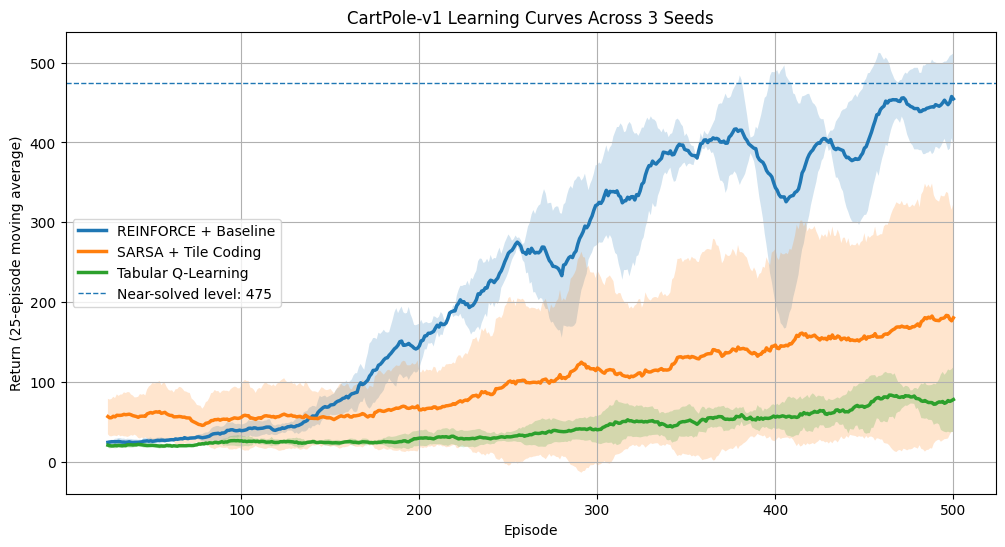

In [11]:
plt.figure(figsize=(12, 6))
window = 25
for algorithm, sub_algo in results_df.groupby("algorithm"):
    seed_curves = []
    for seed, sub_seed in sub_algo.groupby("seed"):
        curve = moving_average(sub_seed.sort_values("episode")["return"].to_numpy(), window=window)
        seed_curves.append(curve)
    seed_curves = np.vstack(seed_curves)
    mean, ci = mean_ci95(seed_curves)
    x = np.arange(len(mean)) + window
    plt.plot(x, mean, linewidth=2.5, label=algorithm)
    plt.fill_between(x, mean - ci, mean + ci, alpha=0.20)

plt.axhline(475, linestyle="--", linewidth=1, label="Near-solved level: 475")
plt.title("CartPole-v1 Learning Curves Across 3 Seeds")
plt.xlabel("Episode")
plt.ylabel(f"Return ({window}-episode moving average)")
plt.legend()
plt.show()

## 9. Final performance bar chart with error bars

Final performance is measured as the average return over the final 100 episodes for each seed. The bar height is the mean across seeds, and the error bar is a 95% confidence interval across seeds.

In [12]:
final_by_seed = summarize_final_performance(results_df, final_window=100)
final_summary = (
    final_by_seed.groupby("algorithm")
    .agg(
        mean_final_return=("final_100_episode_avg", "mean"),
        std_final_return=("final_100_episode_avg", "std"),
        n=("seed", "count"),
        mean_best_return=("best_return", "mean"),
    )
    .reset_index()
)
final_summary["ci95"] = 1.96 * final_summary["std_final_return"].fillna(0) / np.sqrt(final_summary["n"])
final_summary = final_summary.sort_values("mean_final_return", ascending=False)
final_summary

,algorithm,mean_final_return,std_final_return,n,mean_best_return,ci95
0,REINFORCE + Baseline,423.340000,1.321060,3,500.000000,1.494920
1,SARSA + Tile Coding,164.326667,120.988331,3,273.333333,136.911185
2,Tabular Q-Learning,73.090000,21.549220,3,211.000000,24.385238


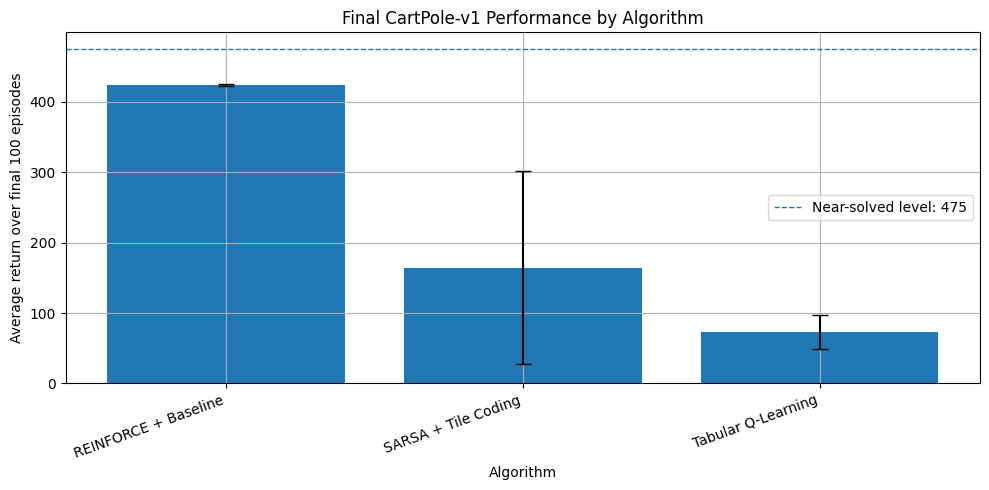

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(final_summary["algorithm"], final_summary["mean_final_return"], yerr=final_summary["ci95"], capsize=6)
plt.axhline(475, linestyle="--", linewidth=1, label="Near-solved level: 475")
plt.title("Final CartPole-v1 Performance by Algorithm")
plt.ylabel("Average return over final 100 episodes")
plt.xlabel("Algorithm")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Brief analysis of differences and trade-offs

**Tabular Q-Learning** is the simplest method because it uses a Q-table and an off-policy TD target. However, CartPole has continuous observations, so the method depends heavily on discretization quality. Coarse bins learn quickly but lose important state information, while fine bins create a large table that needs more experience. This makes tabular Q-learning easy to understand but less natural for CartPole.

**SARSA with Tile Coding** is still a value-based TD method, but it handles continuous observations more smoothly than hard discretization. Multiple overlapping tilings allow nearby states to share information, so learning is usually more stable than a single discretized Q-table. The trade-off is that tile coding requires feature-design choices such as number of tilings, tile resolution, and step size.

**REINFORCE with Baseline** is from the policy-gradient family. It learns a stochastic policy directly from full-episode returns and uses a learned value baseline to reduce variance. This method can represent continuous-state policies naturally with a neural network, but it is usually more sensitive to learning rate, random seed, and gradient variance than TD methods. It may need more episodes or tuning to become reliable, but it scales better to richer continuous-control problems.

Overall, this comparison shows the main trade-off: tabular methods are transparent but struggle with continuous states; tile coding improves value-function generalization with hand-built features; policy gradients are flexible and neural-network based but can be less sample efficient and more variable.

## 11. Save results

In [14]:
os.makedirs("cartpole_algorithm_comparison_results", exist_ok=True)
results_df.to_csv("cartpole_algorithm_comparison_results/training_history.csv", index=False)
final_by_seed.to_csv("cartpole_algorithm_comparison_results/final_by_seed.csv", index=False)
final_summary.to_csv("cartpole_algorithm_comparison_results/final_summary.csv", index=False)

for name, table in tuning_tables.items():
    safe_name = name.lower().replace(" ", "_").replace("+", "plus")
    table.to_csv(f"cartpole_algorithm_comparison_results/tuning_{safe_name}.csv", index=False)

print("Saved CSV outputs to cartpole_algorithm_comparison_results/")

Saved CSV outputs to cartpole_algorithm_comparison_results/
